## Computational Finance Lab Assignment 2
### Binomial Tree Methods
#### Aleksandra Górska, Marcin Pałyga


## Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from scipy.stats import norm

sns.set_theme()
warnings.filterwarnings("ignore")

## 1. European option pricing and convergence

In [3]:
def euro_call(S, K, T, r, sigma, N, model):
    if model == 'CRR':
        dt = T/N
        u = np.exp(sigma * np.sqrt(dt))
        d = 1/u
        p = (np.exp(r*dt) - d) / (u - d)
    elif model == 'JR':
        dt = T/N
        u = np.exp((r-sigma**2/2)*dt + sigma * np.sqrt(dt))
        d = np.exp((r-sigma**2/2)*dt - sigma * np.sqrt(dt))
        p = 0.5
    prices = np.array([S*(u**(N-i))*(d**i) for i in range(N+1)])
    payoffs = np.maximum(prices - K, 0)
    disc = np.exp(-r*dt)
    for j in range(N-1, -1, -1):
        payoffs = disc*(p*payoffs[:-1] + (1-p)*payoffs[1:])
    return payoffs[0]

def euro_put(S, K, T, r, sigma, N, model):
    if model == 'CRR':
        dt = T/N
        u = np.exp(sigma * np.sqrt(dt))
        d = 1/u
        p = (np.exp(r*dt) - d) / (u - d)
    elif model == 'JR':
        dt = T/N
        u = np.exp((r-sigma**2/2)*dt + sigma * np.sqrt(dt))
        d = np.exp((r-sigma**2/2)*dt - sigma * np.sqrt(dt))
        p = 0.5
    prices = np.array([S*(u**(N-i))*(d**i) for i in range(N+1)])
    payoffs = np.maximum(K - prices, 0)
    disc = np.exp(-r*dt)
    for j in range(N-1, -1, -1):
        payoffs = disc*(p*payoffs[:-1] + (1-p)*payoffs[1:])
    return payoffs[0]

def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call_price

def bs_put_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return put_price

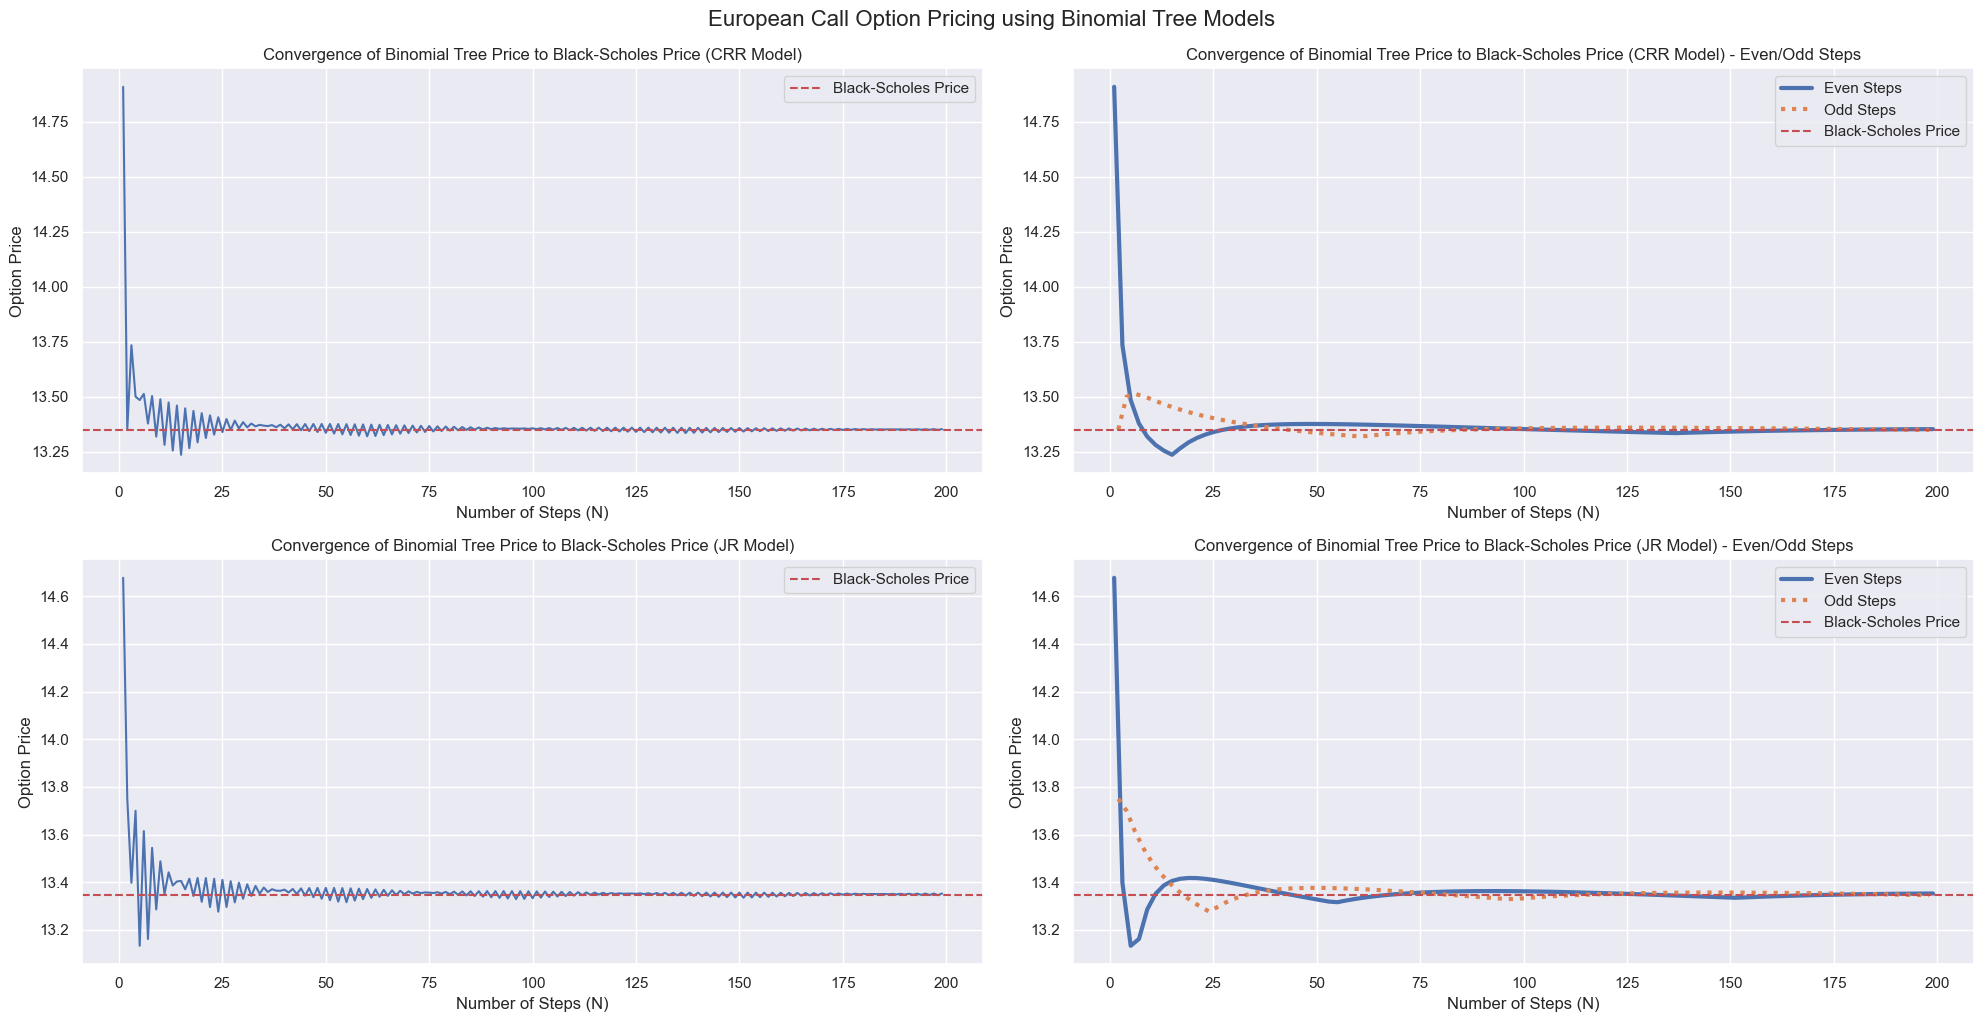

In [32]:
S = 100  
K = 95
T = 1
r = 0.05 
sigma = 0.2 
prices_crr = []
errors_crr = []
prices_jr = []
errors_jr = []
Ns = np.arange(1, 200)
for N in Ns:
    price = euro_call(S, K, T, r, sigma, N, 'CRR')
    prices_crr.append(price)
    errors_crr.append(price - bs_call_price(S, K, T, r, sigma))
    price = euro_call(S, K, T, r, sigma, N, 'JR')
    prices_jr.append(price)
    errors_jr.append(price - bs_call_price(S, K, T, r, sigma))

fig, ((ax1,ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,10))

ax1.plot(Ns, prices_crr)
ax1.axhline(y=bs_call_price(S, K, T, r, sigma), color='r', linestyle='--', label='Black-Scholes Price')
ax1.set_title('Convergence of Binomial Tree Price to Black-Scholes Price (CRR Model)')
ax1.set_xlabel('Number of Steps (N)')
ax1.set_ylabel('Option Price')
ax1.legend()

ax2.plot(Ns[::2], prices_crr[::2], label='Even Steps', linestyle='-', linewidth=3)
ax2.plot(Ns[1::2], prices_crr[1::2], label='Odd Steps', linestyle=':', linewidth=3)
ax2.axhline(y=bs_call_price(S, K, T, r, sigma), color='r', linestyle='--', label='Black-Scholes Price')
ax2.set_title('Convergence of Binomial Tree Price to Black-Scholes Price (CRR Model) - Even/Odd Steps')
ax2.set_xlabel('Number of Steps (N)')
ax2.set_ylabel('Option Price')
ax2.legend()

ax3.plot(Ns, prices_jr)
ax3.axhline(y=bs_call_price(S, K, T, r, sigma), color='r', linestyle='--', label='Black-Scholes Price')
ax3.set_title('Convergence of Binomial Tree Price to Black-Scholes Price (JR Model)')
ax3.set_xlabel('Number of Steps (N)')
ax3.set_ylabel('Option Price')
ax3.legend()

ax4.plot(Ns[::2], prices_jr[::2], label='Even Steps', linestyle='-', linewidth=3)
ax4.plot(Ns[1::2], prices_jr[1::2], label='Odd Steps', linestyle=':', linewidth=3)
ax4.axhline(y=bs_call_price(S, K, T, r, sigma), color='r', linestyle='--', label='Black-Scholes Price')
ax4.set_title('Convergence of Binomial Tree Price to Black-Scholes Price (JR Model) - Even/Odd Steps')
ax4.set_xlabel('Number of Steps (N)')
ax4.set_ylabel('Option Price')
ax4.legend()
plt.tight_layout()
plt.suptitle('European Call Option Pricing using Binomial Tree Models', fontsize=16, y=1.02)
plt.show()

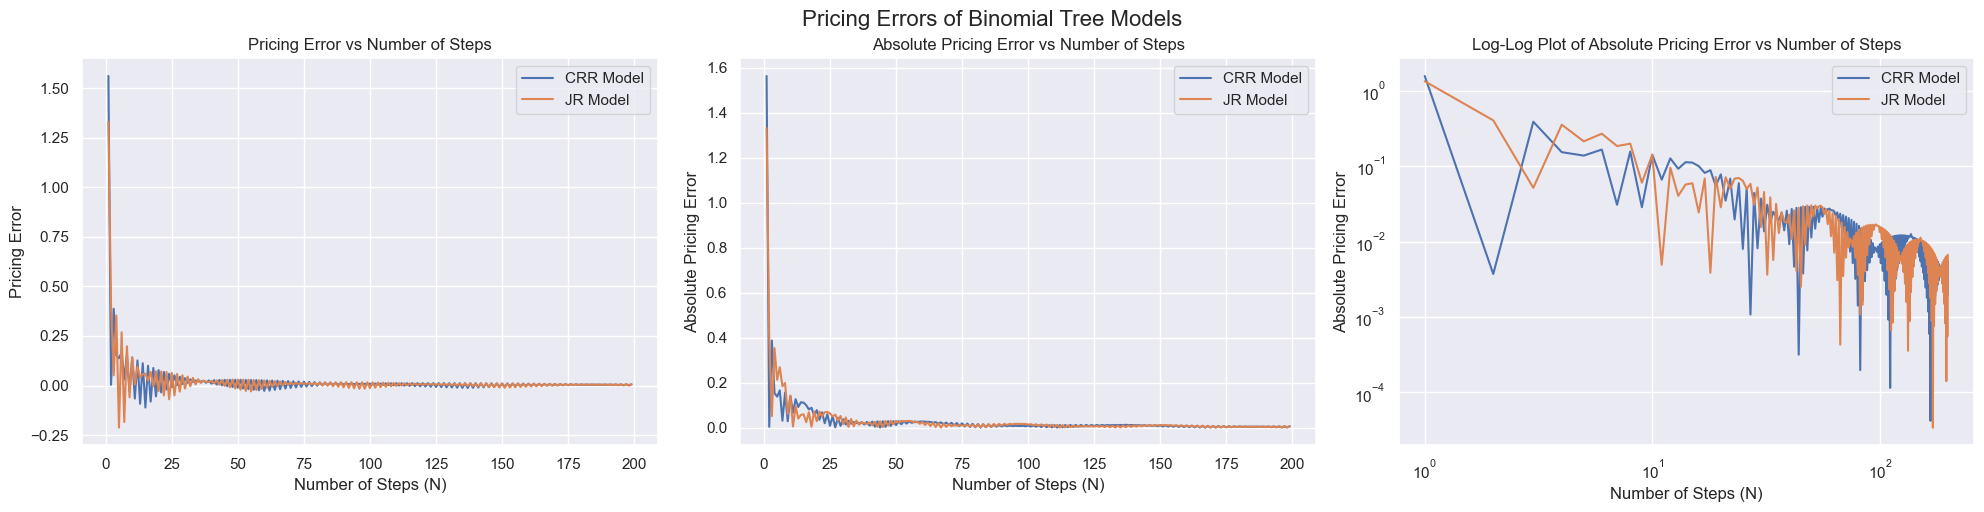

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))
ax1.plot(Ns, errors_crr, label='CRR Model')
ax1.plot(Ns, errors_jr, label='JR Model')
ax1.set_title('Pricing Error vs Number of Steps')
ax1.set_xlabel('Number of Steps (N)')
ax1.set_ylabel('Pricing Error')
ax1.legend()

ax2.plot(Ns, np.abs(errors_crr), label='CRR Model')
ax2.plot(Ns, np.abs(errors_jr), label='JR Model')
ax2.set_title('Absolute Pricing Error vs Number of Steps')
ax2.set_xlabel('Number of Steps (N)')
ax2.set_ylabel('Absolute Pricing Error')
ax2.legend()

ax3.loglog(Ns, np.abs(errors_crr), label='CRR Model')
ax3.loglog(Ns, np.abs(errors_jr), label='JR Model')
ax3.set_title('Log-Log Plot of Absolute Pricing Error vs Number of Steps')
ax3.set_xlabel('Number of Steps (N)')
ax3.set_ylabel('Absolute Pricing Error')
ax3.legend()
plt.tight_layout()
plt.suptitle('Pricing Errors of Binomial Tree Models', fontsize=16, y=1.02)
plt.show()

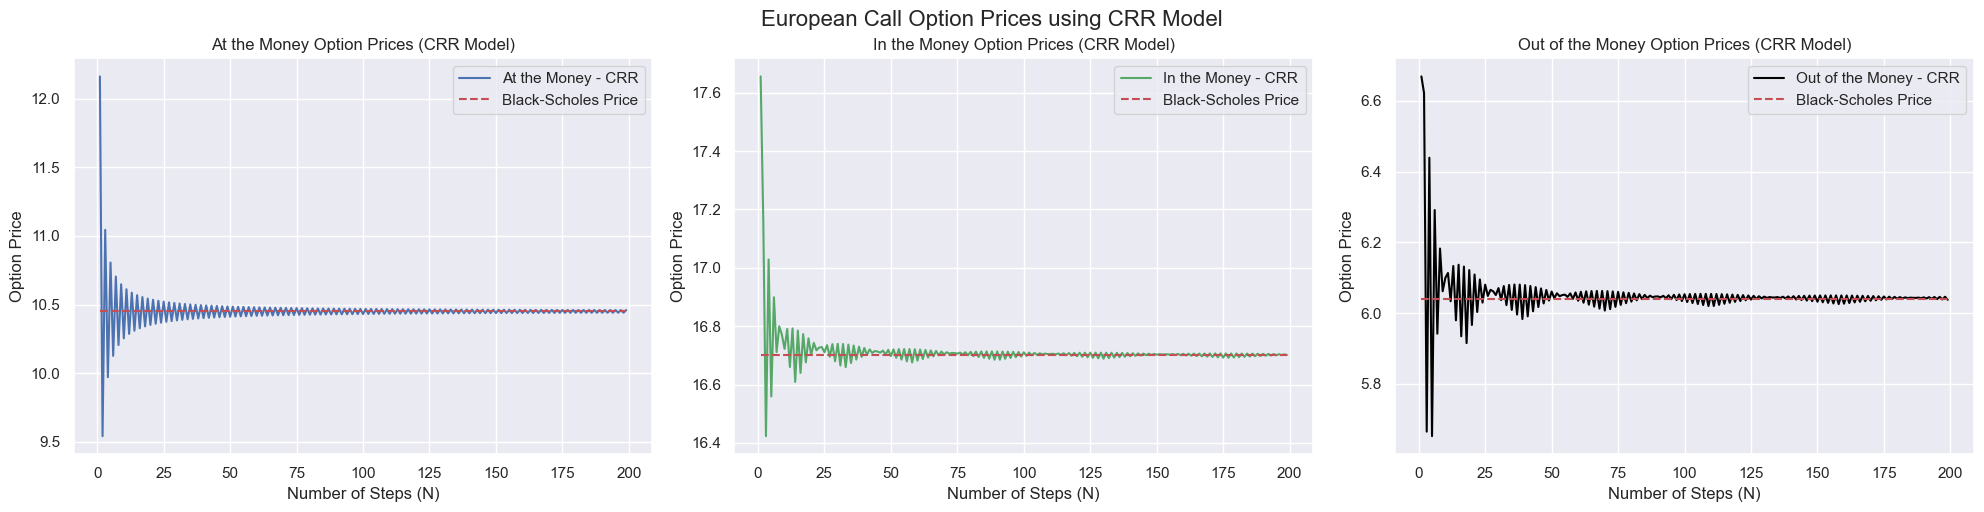

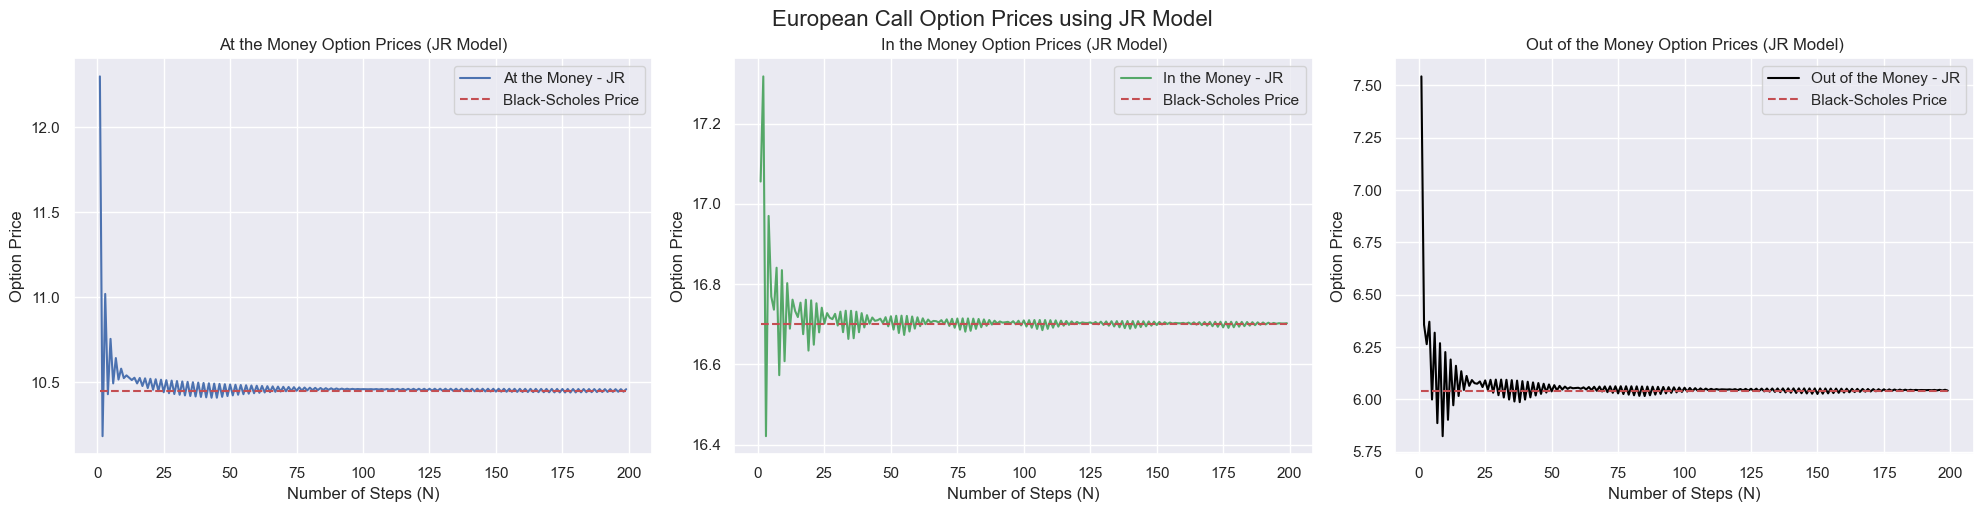

In [39]:
atm_crr_prices = []
atm_jr_prices = []
itm_crr_prices = []
itm_jr_prices = []
otm_crr_prices = []
otm_jr_prices = []
S = 100  
T = 1
r = 0.05 
sigma = 0.2 
for N in Ns:
    atm_crr_prices.append(euro_call(S, S, T, r, sigma, N, 'CRR'))
    atm_jr_prices.append(euro_call(S, S, T, r, sigma, N, 'JR'))
    itm_crr_prices.append(euro_call(S, S*0.9, T, r, sigma, N, 'CRR'))
    itm_jr_prices.append(euro_call(S, S*0.9, T, r, sigma, N, 'JR'))
    otm_crr_prices.append(euro_call(S, S*1.1, T, r, sigma, N, 'CRR'))
    otm_jr_prices.append(euro_call(S, S*1.1, T, r, sigma, N, 'JR'))
bs_atm = bs_call_price(S, S, T, r, sigma)
bs_itm = bs_call_price(S, S*0.9, T, r, sigma)
bs_otm = bs_call_price(S, S*1.1, T, r, sigma)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))
ax1.plot(Ns, atm_crr_prices, label='At the Money - CRR')
ax1.plot(Ns, [bs_atm]*len(Ns), 'r--', label='Black-Scholes Price')
ax1.set_title('At the Money Option Prices (CRR Model)')
ax1.set_xlabel('Number of Steps (N)')
ax1.set_ylabel('Option Price')
ax1.legend()

ax2.plot(Ns, itm_crr_prices, label='In the Money - CRR', color='g')
ax2.plot(Ns, [bs_itm]*len(Ns), 'r--', label='Black-Scholes Price')
ax2.set_title('In the Money Option Prices (CRR Model)')
ax2.set_xlabel('Number of Steps (N)')
ax2.set_ylabel('Option Price')
ax2.legend()

ax3.plot(Ns, otm_crr_prices, label='Out of the Money - CRR', color='black')
ax3.plot(Ns, [bs_otm]*len(Ns), 'r--', label='Black-Scholes Price')
ax3.set_title('Out of the Money Option Prices (CRR Model)')
ax3.set_xlabel('Number of Steps (N)')
ax3.set_ylabel('Option Price')
ax3.legend()
plt.tight_layout()
plt.suptitle('European Call Option Prices using CRR Model', fontsize=16, y=1.02)
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))
ax1.plot(Ns, atm_jr_prices, label='At the Money - JR')
ax1.plot(Ns, [bs_atm]*len(Ns), 'r--', label='Black-Scholes Price')
ax1.set_title('At the Money Option Prices (JR Model)')
ax1.set_xlabel('Number of Steps (N)')
ax1.set_ylabel('Option Price')
ax1.legend()

ax2.plot(Ns, itm_jr_prices, label='In the Money - JR', color='g')
ax2.plot(Ns, [bs_itm]*len(Ns), 'r--', label='Black-Scholes Price')
ax2.set_title('In the Money Option Prices (JR Model)')
ax2.set_xlabel('Number of Steps (N)')
ax2.set_ylabel('Option Price')
ax2.legend()

ax3.plot(Ns, otm_jr_prices, label='Out of the Money - JR', color='black')
ax3.plot(Ns, [bs_otm]*len(Ns), 'r--', label='Black-Scholes Price')
ax3.set_title('Out of the Money Option Prices (JR Model)')
ax3.set_xlabel('Number of Steps (N)')
ax3.set_ylabel('Option Price')
ax3.legend()
plt.tight_layout()
plt.suptitle('European Call Option Prices using JR Model', fontsize=16, y=1.02)
plt.show()

### Comments

- Jarrow-Rudd model tends oscillate for a longer period of time and converges slower
- Looking at error plots Jarrow-Rudd models behaves better for small values of N
- Generally, it's hard to tell which model is better to use for European options, it may vary according to changes in parameters

## 2. American options (calls and puts)

In [89]:
def amer_call(S, K, T, r, sigma, N, model):
    if model == 'CRR':
        dt = T/N
        u = np.exp(sigma * np.sqrt(dt))
        d = 1/u
        p = (np.exp(r*dt) - d) / (u - d)
    elif model == 'JR':
        dt = T/N
        u = np.exp((r-sigma**2/2)*dt + sigma * np.sqrt(dt))
        d = np.exp((r-sigma**2/2)*dt - sigma * np.sqrt(dt))
        p = 0.5
    disc = np.exp(-r*dt)   
    prices = np.array([S*(u**(N-i))*(d**i) for i in range(N+1)])
    payoffs = np.maximum(prices - K, 0)
    for j in range(N-1, -1, -1):
        prices = np.array([S*(u**(j-i))*(d**i) for i in range(j+1)])
        hold = disc*(p*payoffs[:-1] + (1-p)*payoffs[1:])
        exercise = np.maximum(prices - K, 0)
        payoffs = np.maximum(exercise, hold)
    return payoffs[0]

def amer_put(S, K, T, r, sigma, N, model):
    if model == 'CRR':
        dt = T/N
        u = np.exp(sigma * np.sqrt(dt))
        d = 1/u
        p = (np.exp(r*dt) - d) / (u - d)
    elif model == 'JR':
        dt = T/N
        u = np.exp((r-sigma**2/2)*dt + sigma * np.sqrt(dt))
        d = np.exp((r-sigma**2/2)*dt - sigma * np.sqrt(dt))
        p = 0.5
    disc = np.exp(-r*dt)   
    prices = np.array([S*(u**(N-i))*(d**i) for i in range(N+1)])
    payoffs = np.maximum(K - prices, 0)
    for j in range(N-1, -1, -1):
        prices = np.array([S*(u**(j-i))*(d**i) for i in range(j+1)])
        hold = disc*(p*payoffs[:-1] + (1-p)*payoffs[1:])
        exercise = np.maximum(K - prices, 0)
        payoffs = np.maximum(exercise, hold)
    return payoffs[0]

In [90]:
S0 = 100
K = 110
T = 1
r = 0.05
sigma = 0.2
N = 100
amer_call_crr = amer_call(S0, K, T, r, sigma, N, 'CRR')
euro_call_crr = euro_call(S0, K, T, r, sigma, N, 'CRR')
bs = bs_call_price(S0, K, T, r, sigma)
print(f"American Call Price (CRR): {amer_call_crr:.4f}")
print(f"European Call Price (CRR): {euro_call_crr:.4f}")
print(f"Black-Scholes Call Price: {bs:.4f}")
print(f"Early Exercise Premium (CRR): {amer_call_crr - euro_call_crr:.4f}\n")

American Call Price (CRR): 6.0532
European Call Price (CRR): 6.0532
Black-Scholes Call Price: 6.0401
Early Exercise Premium (CRR): 0.0000



In [91]:
S0 = 100
K = 110
T = 1
r = 0.05
sigma = 0.2
N = 100
amer_put_crr = amer_put(S0, K, T, r, sigma, N, 'CRR')
euro_put_crr = euro_put(S0, K, T, r, sigma, N, 'CRR')
bs = bs_put_price(S0, K, T, r, sigma)
print(f"American Put Price (CRR): {amer_put_crr:.4f}")
print(f"European Put Price (CRR): {euro_put_crr:.4f}")
print(f"Black-Scholes Put Price: {bs:.4f}")
print(f"Early Exercise Premium (CRR): {amer_put_crr - euro_put_crr:.4f}\n")


American Put Price (CRR): 11.9812
European Put Price (CRR): 10.6885
Black-Scholes Put Price: 10.6753
Early Exercise Premium (CRR): 1.2927



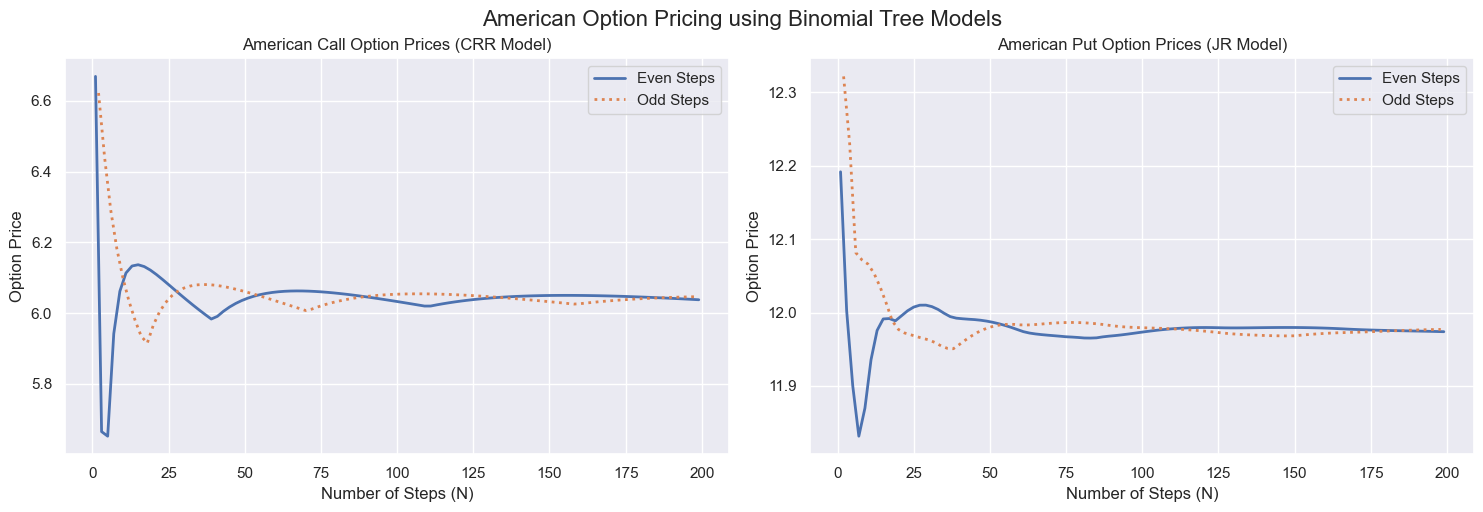

In [93]:
amer_calls_crr = []
amer_puts_crr = []
amer_calls_jr = []
amer_puts_jr = []
for N in Ns:
    amer_calls_crr.append(amer_call(S0, K, T, r, sigma, N, 'CRR'))
    amer_puts_crr.append(amer_put(S0, K, T, r, sigma, N, 'CRR'))
    amer_calls_jr.append(amer_call(S0, K, T, r, sigma, N, 'JR'))
    amer_puts_jr.append(amer_put(S0, K, T, r, sigma, N, 'JR'))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
ax1.plot(Ns[::2], amer_calls_crr[::2], label='Even Steps', linestyle='-', linewidth=2)
ax1.plot(Ns[1::2], amer_calls_crr[1::2], label='Odd Steps', linestyle=':', linewidth=2)
ax1.set_title('American Call Option Prices (CRR Model)')
ax1.set_xlabel('Number of Steps (N)')
ax1.set_ylabel('Option Price')
ax1.legend()

ax2.plot(Ns[::2], amer_puts_jr[::2], label='Even Steps', linestyle='-', linewidth=2)
ax2.plot(Ns[1::2], amer_puts_jr[1::2], label='Odd Steps', linestyle=':', linewidth=2)
ax2.set_title('American Put Option Prices (JR Model)')
ax2.set_xlabel('Number of Steps (N)')
ax2.set_ylabel('Option Price')
ax2.legend()
plt.tight_layout()
plt.suptitle('American Option Pricing using Binomial Tree Models', fontsize=16, y=1.02)
plt.show()

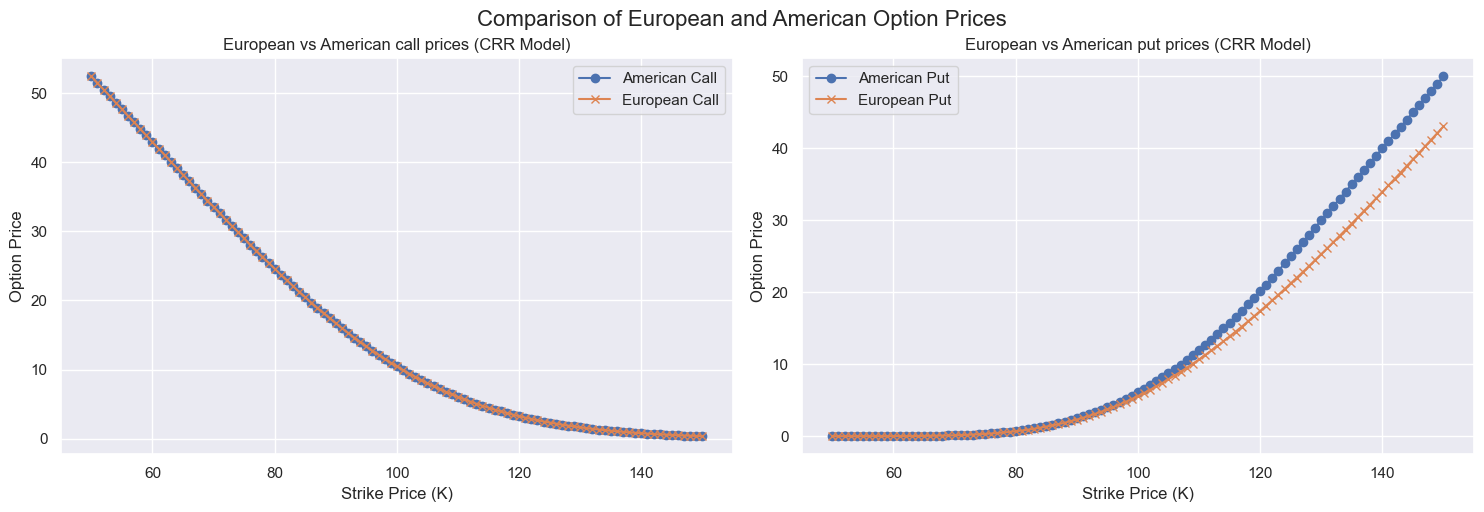

In [96]:
Ks = np.arange(50, 151, 1)
S0 = 100
T = 1
r = 0.05
sigma = 0.2
amer_calls = []
euro_calls = []
amer_puts = []
euro_puts = []
for K in Ks:
    amer_calls.append(amer_call(S0, K, T, r, sigma, N, 'CRR'))
    euro_calls.append(euro_call(S0, K, T, r, sigma, N, 'CRR'))
    amer_puts.append(amer_put(S0, K, T, r, sigma, N, 'CRR'))
    euro_puts.append(euro_put(S0, K, T, r, sigma, N, 'CRR'))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
ax1.plot(Ks, amer_calls, label='American Call', marker='o')
ax1.plot(Ks, euro_calls, label='European Call', marker='x')
ax1.set_title('European vs American call prices (CRR Model)')
ax1.set_xlabel('Strike Price (K)')
ax1.set_ylabel('Option Price')
ax1.legend()

ax2.plot(Ks, amer_puts, label='American Put', marker='o')
ax2.plot(Ks, euro_puts, label='European Put', marker='x')
ax2.set_title('European vs American put prices (CRR Model)')
ax2.set_xlabel('Strike Price (K)')
ax2.set_ylabel('Option Price')
ax2.legend()
plt.tight_layout()
plt.suptitle('Comparison of European and American Option Prices', fontsize=16, y=1.02)
plt.show()

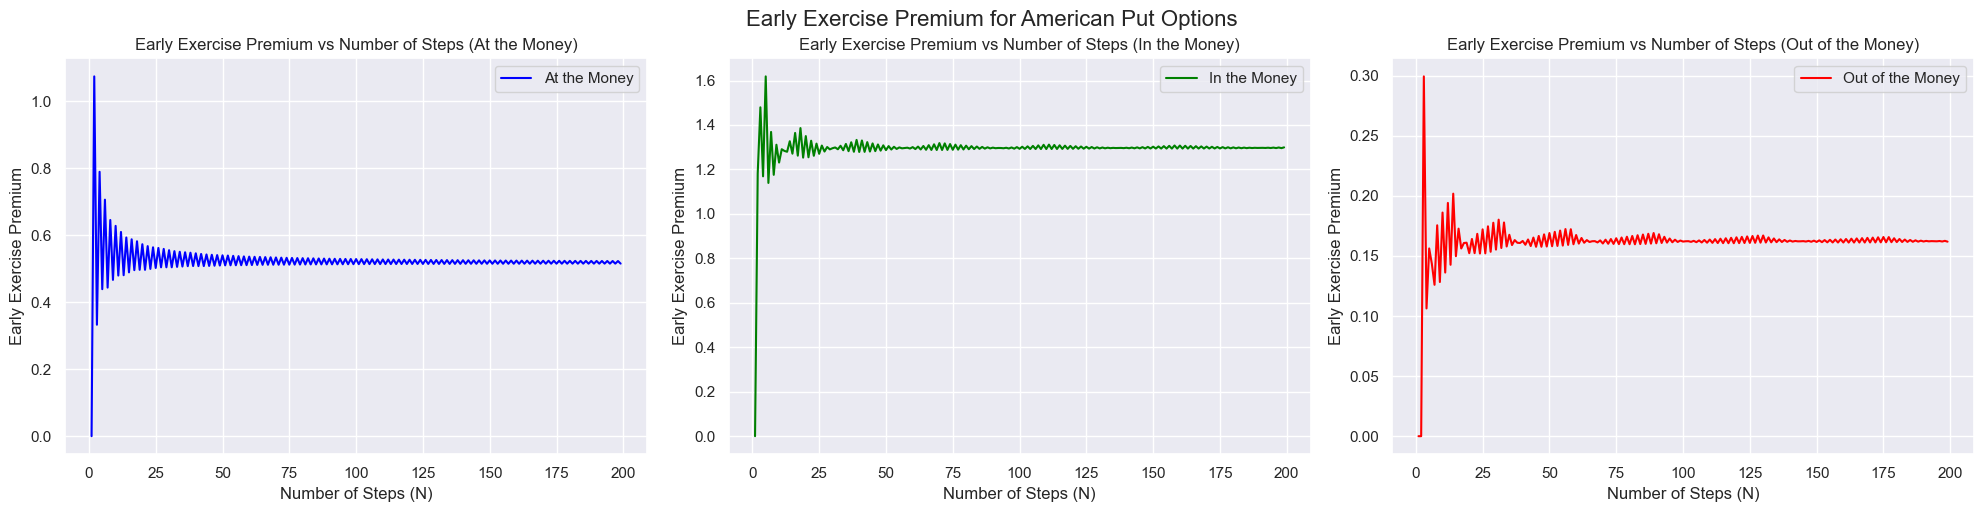

In [98]:
S0 = 100
T = 1
r = 0.05
sigma = 0.2
atm_diff = []
itm_diff = []
otm_diff = []
for N in Ns:
    atm_diff.append(amer_put(S0, S0, T, r, sigma, N, 'CRR') - euro_put(S0, S0, T, r, sigma, N, 'CRR'))
    itm_diff.append(amer_put(S0, S0*1.1, T, r, sigma, N, 'CRR') - euro_put(S0, S0*1.1, T, r, sigma, N, 'CRR'))
    otm_diff.append(amer_put(S0, S0*0.9, T, r, sigma, N, 'CRR') - euro_put(S0, S0*0.9, T, r, sigma, N, 'CRR'))

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))
ax1.plot(Ns, atm_diff, label='At the Money', color='blue')
ax1.set_title('Early Exercise Premium vs Number of Steps (At the Money)')
ax1.set_xlabel('Number of Steps (N)')
ax1.set_ylabel('Early Exercise Premium')
ax1.legend()

ax2.plot(Ns, itm_diff, label='In the Money', color='green')
ax2.set_title('Early Exercise Premium vs Number of Steps (In the Money)')
ax2.set_xlabel('Number of Steps (N)')
ax2.set_ylabel('Early Exercise Premium')
ax2.legend()

ax3.plot(Ns, otm_diff, label='Out of the Money', color='red')
ax3.set_title('Early Exercise Premium vs Number of Steps (Out of the Money)')
ax3.set_xlabel('Number of Steps (N)')
ax3.set_ylabel('Early Exercise Premium')
ax3.legend()
plt.tight_layout()
plt.suptitle('Early Exercise Premium for American Put Options', fontsize=16, y=1.02)
plt.show()

### Comments
- Prices of American option oscillate in similar way to European options
- As we can see for non-divedend paying stocks European and American calls are equal, and for puts we can say that $P_{american} \ge P_{european}$
- Early exercise premiums also oscillate similarly as american and european options

## 4. Vasicek zero-coupon bond pricing

In [106]:
def P_closed(r0, alpha, beta, sigma, T):
    A = (1-np.exp(-beta*T)) / beta
    D = (alpha-0.5*sigma**2/beta**2)*(A - T) - (sigma**2/(4*beta))*(A**2)
    return np.exp(-A*r0 + D)

def P_lattice(r0, alpha, beta, sigma, T, N):
    dt = T/N
    u = sigma * np.sqrt(dt)
    prices = np.ones(N+1)
    for i in range(N-1, -1, -1):
        curr = np.zeros(i+1)
        for j in range(i+1):
            r = r0 + j*u - (i-j)*u
            p = 0.5 + beta*(alpha - r)*np.sqrt(dt)/(2*sigma) 
            if p < 0:
                p = 0
            elif p > 1:
                p = 1
            disc = np.exp(-r*dt)
            curr[j] = disc*(p*prices[j+1] + (1-p)*prices[j])
        prices = curr
    return prices[0]


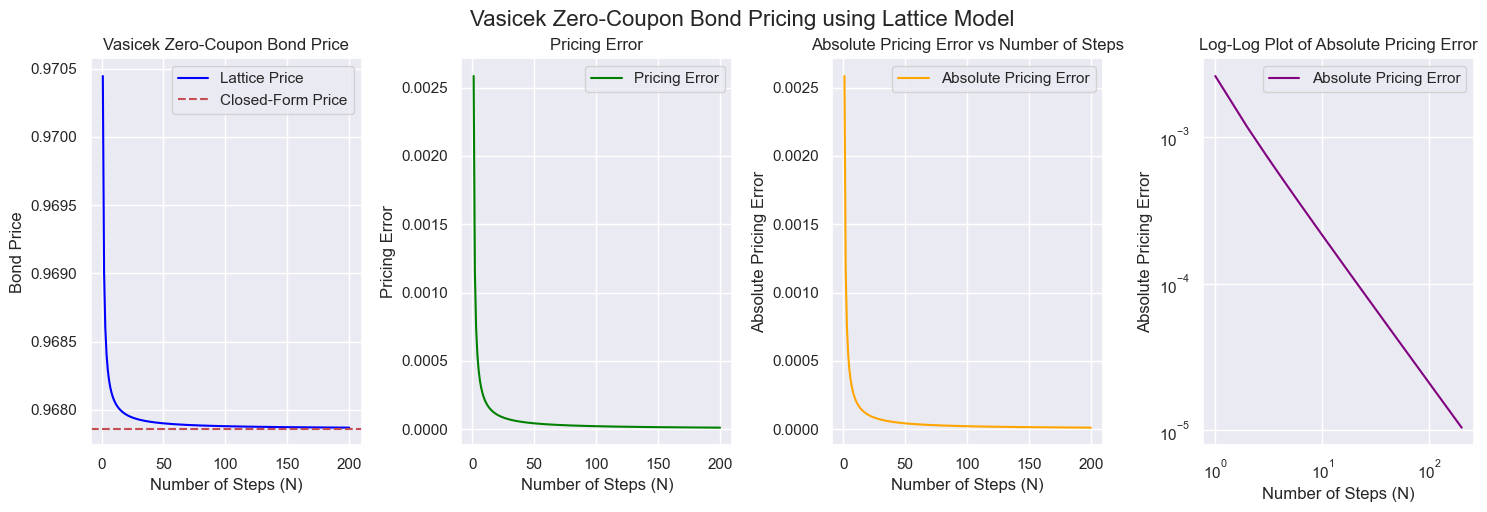

In [107]:
r0, alpha, beta, sigma, T = 0.03, 0.05, 0.3, 0.02, 1
P_ref = P_closed(r0, alpha, beta, sigma, T)
results = []
Ns = np.arange(1, 201)
for N in Ns:
    P_approx = P_lattice(r0, alpha, beta, sigma, T, N)
    plain_error = P_approx - P_ref
    absolute_error = abs(plain_error)
    results.append((N, P_approx, plain_error, absolute_error))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(15,5))
ax1.plot(Ns, [res[1] for res in results], label='Lattice Price', color='blue')
ax1.axhline(y=P_ref, color='r', linestyle='--', label='Closed-Form Price')
ax1.set_title('Vasicek Zero-Coupon Bond Price')
ax1.set_xlabel('Number of Steps (N)')
ax1.set_ylabel('Bond Price')
ax1.legend()

ax2.plot(Ns, [res[2] for res in results], label='Pricing Error', color='green')
ax2.set_title('Pricing Error')
ax2.set_xlabel('Number of Steps (N)')
ax2.set_ylabel('Pricing Error')
ax2.legend()

ax3.plot(Ns, [res[3] for res in results], label='Absolute Pricing Error', color='orange')
ax3.set_title('Absolute Pricing Error vs Number of Steps')
ax3.set_xlabel('Number of Steps (N)')
ax3.set_ylabel('Absolute Pricing Error')
ax3.legend()

ax4.loglog(Ns, [res[3] for res in results], label='Absolute Pricing Error', color='purple')
ax4.set_title('Log-Log Plot of Absolute Pricing Error')
ax4.set_xlabel('Number of Steps (N)')
ax4.set_ylabel('Absolute Pricing Error')
ax4.legend()
plt.tight_layout()
plt.suptitle('Vasicek Zero-Coupon Bond Pricing using Lattice Model', fontsize=16, y=1.02)
plt.show()


### Comments
- Prices using lattices for Vasicek Zero-Coupon Bonds converge pretty fast to closed form price 
- Log-log plot of absolute errors is linear confirming consistent convergence rate across tested range